In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import os
import sys
from pathlib import Path

module_path = os.path.abspath(os.path.join(".."))
if module_path not in sys.path:
    sys.path.append(module_path)

from utils.color_utils import single_hex_list_to_lab_arr

In [2]:
def analyze_palette_size(data):
    sizes = [len(item["palette"]) for item in data]
    counts = Counter(sizes)

    print("Palette size distribution:")
    for size, count in sorted(counts.items()):
        print(f"  {size}: {count} ({ count / len(data) * 100:.2f}%)")

    plt.figure(figsize=(5, 3), dpi=150)
    plt.hist(
        sizes,
        bins=range(min(sizes), max(sizes) + 2),
        align="left",
    )
    plt.xlabel("Palette size")
    plt.ylabel("Count")
    plt.title("Palette Size Distribution")
    plt.tight_layout()
    plt.show()
    plt.close()


def analyze_lab_space(data):
    labs = []

    for item in data:
        lab = single_hex_list_to_lab_arr(item["palette"])  # (N, 3)
        labs.append(lab)

    labs = np.vstack(labs)
    L, a, b = labs[:, 0], labs[:, 1], labs[:, 2]

    chroma = np.sqrt(a**2 + b**2)

    print("LAB color distribution:")
    print(f"L* mean: {L.mean():.2f}")
    print(f"a* mean: {a.mean():.2f}")
    print(f"b* mean: {b.mean():.2f}")
    print(f"Mean chroma (sqrt(a^2 + b^2)): {chroma.mean():.2f}")

    plt.figure(figsize=(5, 5), dpi=150)
    ax = plt.gca()
    ax.set_facecolor("#1a1a1a")

    sc = ax.scatter(
        a,
        b,
        c=L,
        cmap="gray",
        s=6,
        alpha=0.8,
        edgecolors="none",
    )

    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)

    ax.set_xlabel("a* (green ↔ red)")
    ax.set_ylabel("b* (blue ↔ yellow)")
    ax.set_title("LAB Color Distribution")

    plt.colorbar(sc, label="Lightness (L*)")
    ax.set_aspect("equal")

    plt.show()
    plt.close()

The training dataset is not released. Refer to README.md for details.

In [ ]:
dataset_path = "text-palette-dataset.jsonl"

Dataset contains 98863 palettes
Palette size distribution:
  2: 140 (0.14%)
  3: 543 (0.55%)
  4: 4362 (4.41%)
  5: 93665 (94.74%)
  6: 113 (0.11%)
  7: 31 (0.03%)
  8: 9 (0.01%)


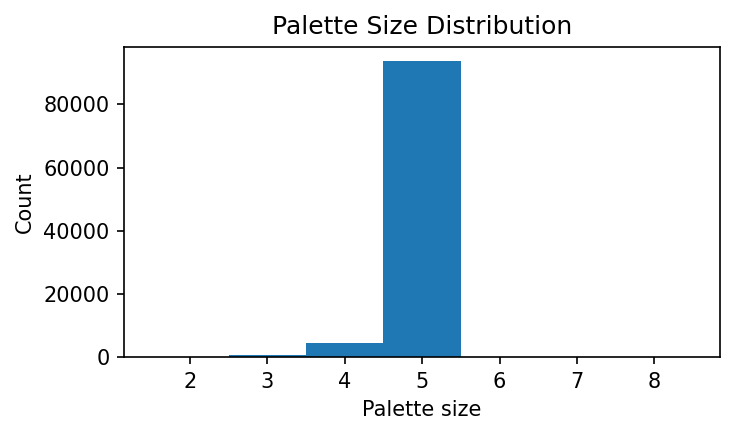

LAB color distribution:
L* mean: 0.61
a* mean: 0.06
b* mean: 0.06
Mean chroma (sqrt(a^2 + b^2)): 0.28


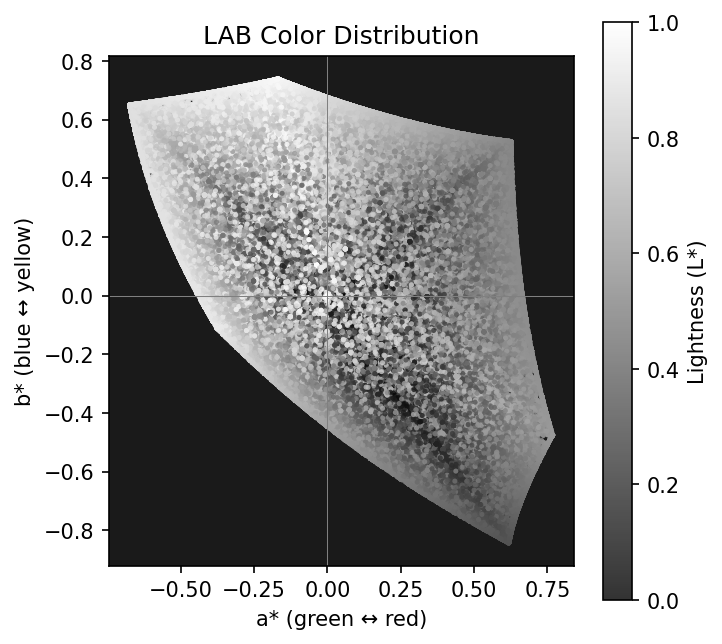

In [4]:
data = []
with open(dataset_path, encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        data.append(json.loads(line))


print(f"Dataset contains {len(data)} palettes")

analyze_palette_size(data)
analyze_lab_space(data)